# Transformer



This notebook is designed as a career-focused transformer learning notebook. Our path starts from high-level theory, then moves into PyTorch's built-in Transformer tools, then rebuilds encoder and decoder blocks from scratch using Python OOP, and finally trains a small Transformer-style classifier on a scikit-learn dataset.

### Learning objectives

By the end of this notebook, we should be able to explain and implement:

- Why Transformers replaced many RNN/CNN sequence workflows.
- Token embeddings, positional encodings, self-attention, masked self-attention, cross-attention, residual connections, layer normalization, and feed-forward networks.
- Encoder-only, decoder-only, and encoder-decoder architecture families.
- PyTorch `nn.MultiheadAttention`, `nn.TransformerEncoderLayer`, `nn.TransformerDecoderLayer`, and `nn.Transformer`.
- Fully custom Multi-Head Attention, Encoder Block, Decoder Block, Encoder stack, Decoder stack, and Seq2Seq Transformer.
- Training loops, masking, loss, evaluation, and common interview points.
- A complete Transformer-style pipeline on the scikit-learn digits dataset.

##  Environment setup

The notebook is CPU-friendly. GPU can still be used automatically when available.

Main packages:

- `torch` for deep learning.
- `sklearn` for dataset loading and evaluation.
- `numpy` for array handling.
- `matplotlib` for simple visualization.

In [1]:
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# Small educational models often run faster with fewer CPU threads.
torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

PyTorch version: 2.11.0+cpu
Device: cpu


## Transformer roadmap

A Transformer is a neural network architecture based mainly on attention. Instead of processing sequence elements one after another like a basic RNN, a Transformer compares all sequence positions with all other positions in parallel.

### Big picture

| Component | Main role | Interview explanation |
|---|---|---|
| Tokenization | Converts raw text or other input into discrete units | Model cannot process raw text directly, so text becomes token IDs |
| Embedding | Converts token IDs into dense vectors | Learned representation of meaning or signal |
| Positional encoding | Adds order information | Attention alone is permutation-invariant |
| Self-attention | Lets every token look at other tokens | Learns contextual representation |
| Multi-head attention | Runs attention in several representation subspaces | Different heads can focus on different relations |
| Feed-forward network | Nonlinear transformation at each position | Adds capacity after attention mixing |
| Residual connection | Adds input back to block output | Improves gradient flow |
| Layer normalization | Stabilizes activations | Helps optimization |
| Masking | Blocks illegal attention | Needed for padding and autoregressive decoding |
| Encoder | Builds contextual source representations | Used in BERT-like models and source side of seq2seq |
| Decoder | Generates target sequence step by step | Used in GPT-like and seq2seq generation models |

## Why Transformers became important

### Earlier sequence models

RNN/LSTM/GRU models process tokens sequentially. This makes long-range dependencies difficult and training less parallelizable. CNN-based sequence models can train faster than RNNs, but local kernels need many layers or dilation to capture distant relationships.

### Transformer advantage

Self-attention directly connects any two positions in a sequence. For a sequence length `L`, each token can attend to all `L` tokens in one layer. This makes Transformers strong for language, images, audio, tabular sequences, protein sequences, recommendation logs, time-series windows, and multimodal learning.

### Main limitation

Standard full attention has quadratic sequence cost. Attention scores have shape `[batch, heads, query_length, key_length]`, so memory and compute increase roughly with `L²`.

## Shape notation used throughout

We keep one consistent notation:

- `B` = batch size
- `S` = source sequence length
- `T` = target sequence length
- `L` = generic sequence length
- `D` = model dimension, also called `d_model`
- `H` = number of attention heads
- `Dh` = per-head dimension, equal to `D / H`
- `V` = vocabulary size
- `C` = number of classes

Most code in this notebook uses `batch_first=True`, meaning tensors usually follow:

```text
[batch, sequence_length, feature_dimension]
```

## Attention intuition

For each token, attention asks three questions:

1. **Query**: what is the current token looking for?
2. **Key**: what information does each token offer for matching?
3. **Value**: what information should be collected after matching?

The core formula is:

```text
Attention(Q, K, V) = softmax((QKᵀ) / sqrt(d_k)) V
```

Why divide by `sqrt(d_k)`?

- Dot products become larger when vector dimension grows.
- Large dot products push softmax into saturated regions.
- Scaling keeps gradients healthier.

### Interview answer

Self-attention computes contextual representations by comparing each token's query with every token's key, converting those similarity scores into attention weights, and using those weights to mix value vectors.

## First view through PyTorch built-ins

Before building a custom Transformer, we first inspect PyTorch's reference layers. This gives a working mental model for shapes and API behavior.

In [2]:
# Built-in MultiheadAttention demo
B, L, D, H = 2, 5, 32, 4
x = torch.randn(B, L, D)

mha = nn.MultiheadAttention(embed_dim=D, num_heads=H, batch_first=True)
out, attn_weights = mha(query=x, key=x, value=x, need_weights=True)

print("Input shape:           ", x.shape)
print("MHA output shape:      ", out.shape)
print("Attention weight shape:", attn_weights.shape)

Input shape:            torch.Size([2, 5, 32])
MHA output shape:       torch.Size([2, 5, 32])
Attention weight shape: torch.Size([2, 5, 5])


### Reading the output

- Input shape is `[B, L, D]`.
- Output shape stays `[B, L, D]`.
- Attention weights are usually `[B, L, L]` when averaged over heads.

The attention module does not change sequence length. It changes each token representation by mixing information from other tokens.

In [3]:
# Built-in full Transformer demo
B, S, T, D, H = 2, 6, 4, 32, 4
src = torch.randn(B, S, D)
tgt = torch.randn(B, T, D)

transformer = nn.Transformer(
    d_model=D,
    nhead=H,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    batch_first=True,
)

full_out = transformer(src=src, tgt=tgt)
print("src shape:        ", src.shape)
print("tgt shape:        ", tgt.shape)
print("Transformer output:", full_out.shape)

src shape:         torch.Size([2, 6, 32])
tgt shape:         torch.Size([2, 4, 32])
Transformer output: torch.Size([2, 4, 32])


### PyTorch built-in Transformer anatomy

`nn.Transformer` contains:

- Encoder stack: repeated encoder layers.
- Decoder stack: repeated decoder layers.
- Multi-head attention inside encoder and decoder.
- Feed-forward networks.
- Residual connections and layer normalization.

PyTorch expects embeddings as input. In many real systems, tokenization and embedding layers are added outside `nn.Transformer`.

In [4]:
# Built-in encoder layer and decoder layer demo
encoder_layer = nn.TransformerEncoderLayer(
    d_model=D,
    nhead=H,
    dim_feedforward=128,
    dropout=0.1,
    batch_first=True,
)
encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

memory = encoder(src)
print("Encoder memory shape:", memory.shape)

decoder_layer = nn.TransformerDecoderLayer(
    d_model=D,
    nhead=H,
    dim_feedforward=128,
    dropout=0.1,
    batch_first=True,
)
decoder = nn.TransformerDecoder(decoder_layer, num_layers=2)
decoded = decoder(tgt=tgt, memory=memory)
print("Decoder output shape:", decoded.shape)

Encoder memory shape: torch.Size([2, 6, 32])
Decoder output shape: torch.Size([2, 4, 32])


## Encoder, decoder, and architecture families

### Encoder-only

Used when the model reads the whole input and returns a representation. Common tasks:

- Classification
- Named entity recognition
- Semantic search embedding
- Reranking
- Feature extraction

BERT-style systems are encoder-only. They use bidirectional attention, so each token can attend left and right.

### Decoder-only

Used when the model generates one token at a time. Common tasks:

- Text generation
- Chat completion
- Code generation
- Autoregressive language modeling

GPT-style systems are decoder-only. They use causal masking so each token can only attend to earlier positions.

### Encoder-decoder

Used when source and target are both sequences. Common tasks:

- Translation
- Summarization
- Question answering over a source passage
- Speech recognition variants

T5-style and original seq2seq Transformer systems use an encoder-decoder pattern.

## Positional information

Self-attention by itself does not know token order. The set `[A, B, C]` and `[C, B, A]` would look similar without position information.

Common solutions:

- **Sinusoidal positional encoding**: deterministic sine/cosine values.
- **Learned positional embedding**: learned position vectors.
- **Relative position bias**: attention scores depend on relative distance.
- **Rotary position embedding**: rotates query and key vectors based on position.

### Sinusoidal formula

```text
PE(pos, 2i)   = sin(pos / 10000^(2i / D))
PE(pos, 2i+1) = cos(pos / 10000^(2i / D))
```

### Interview answer

Positional encodings inject order because attention is naturally permutation-invariant. Without them, a Transformer cannot distinguish token positions reliably.

torch.Size([50, 32])


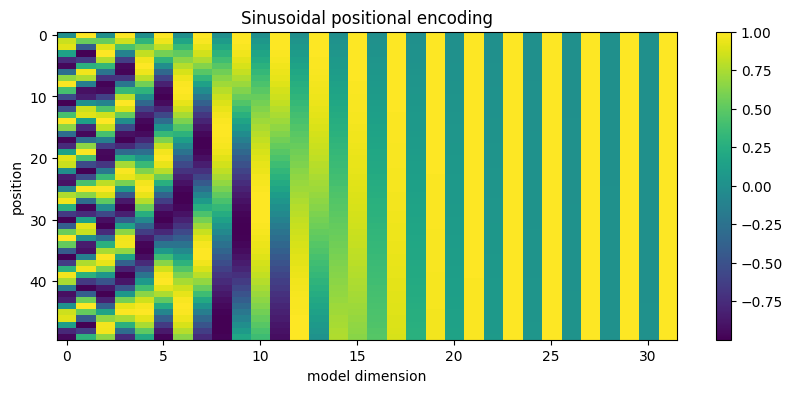

In [5]:
def build_sinusoidal_encoding(max_len: int, d_model: int) -> torch.Tensor:
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pe = build_sinusoidal_encoding(max_len=50, d_model=32)
print(pe.shape)

plt.figure(figsize=(10, 4))
plt.imshow(pe.numpy(), aspect="auto")
plt.title("Sinusoidal positional encoding")
plt.xlabel("model dimension")
plt.ylabel("position")
plt.colorbar()
plt.show()

## Masking

Masking controls which positions attention may see.

### Padding mask

Used when sequences in a batch have different lengths. Padding tokens should not influence real tokens.

Example shape:

```text
[B, 1, 1, S]
```

### Causal mask

Used in decoder-only and decoder self-attention. Token `t` cannot look at tokens after `t`.

Example shape:

```text
[1, 1, T, T]
```

### Cross-attention mask

Used when decoder attends to encoder memory. Usually combines target queries with source padding awareness.

### Common interview trap

A padding mask and a causal mask solve different problems. Padding mask removes fake tokens. Causal mask prevents future leakage.

In [6]:
def make_padding_mask(token_ids: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
    """Return True/1 for valid tokens, False/0 for padding tokens."""
    return (token_ids != pad_idx).unsqueeze(1).unsqueeze(2)


def make_causal_mask(seq_len: int, device: torch.device | str = "cpu") -> torch.Tensor:
    """Return lower-triangular causal mask with shape [1, 1, L, L]."""
    return torch.tril(torch.ones(seq_len, seq_len, device=device)).bool().unsqueeze(0).unsqueeze(0)

sample_tokens = torch.tensor([[5, 7, 9, 0, 0], [4, 2, 3, 8, 0]])
print("Padding mask shape:", make_padding_mask(sample_tokens).shape)
print(make_padding_mask(sample_tokens).int())
print("Causal mask shape:", make_causal_mask(5).shape)
print(make_causal_mask(5).int()[0, 0])

Padding mask shape: torch.Size([2, 1, 1, 5])
tensor([[[[1, 1, 1, 0, 0]]],


        [[[1, 1, 1, 1, 0]]]], dtype=torch.int32)
Causal mask shape: torch.Size([1, 1, 5, 5])
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)


## Training objectives

Different Transformer families use different objectives:

| Family | Objective | Example task |
|---|---|---|
| Encoder-only | masked token prediction, classification loss, contrastive loss | BERT-like classification |
| Decoder-only | next-token prediction | GPT-like generation |
| Encoder-decoder | teacher-forced next-token prediction over target sequence | translation, summarization |
| Vision Transformer | classification loss over image patches | image classification |

### Teacher forcing

For seq2seq training, target input is shifted right. The model receives previous target tokens and predicts the next token.

Example:

```text
Target sentence:    <bos> we learn transformers <eos>
Decoder input:      <bos> we learn transformers
Expected output:    we learn transformers <eos>
```

## Transformer block math

### Encoder block

```text
x1 = x + MultiHeadSelfAttention(LayerNorm(x))
x2 = x1 + FeedForward(LayerNorm(x1))
```

The above is a **Pre-LN** design. Pre-LN is commonly more stable for deeper models.

### Decoder block

```text
y1 = y + MaskedSelfAttention(LayerNorm(y))
y2 = y1 + CrossAttention(LayerNorm(y1), memory)
y3 = y2 + FeedForward(LayerNorm(y2))
```

### Feed-forward network

The feed-forward network is applied independently to every token position:

```text
FFN(x) = Linear2(Dropout(Activation(Linear1(x))))
```

Usually, hidden dimension is larger than model dimension, often around `4 * d_model` in classic designs.

# Part A — Custom Transformer from scratch using Python OOP

Now we build a custom Transformer implementation. The goal is conceptual clarity and interview readiness, not extreme speed.

Custom components:

1. Scaled dot-product attention
2. Multi-head attention
3. Position-wise feed-forward network
4. Sinusoidal positional encoding
5. Encoder block
6. Decoder block
7. Encoder stack
8. Decoder stack
9. Encoder-decoder sequence model

In [7]:
class ScaledDotProductAttention(nn.Module):
    """Scaled dot-product attention.

    Mask convention:
    - mask == 1 or True means attention is allowed.
    - mask == 0 or False means attention is blocked.
    """

    def __init__(self, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        v: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, torch.finfo(scores.dtype).min)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        output = torch.matmul(attn, v)
        return output, attn

In [8]:
class MultiHeadAttentionCustom(nn.Module):
    """Custom multi-head attention with batch-first tensors.

    Input shape:
    - query: [B, T, D]
    - key:   [B, S, D]
    - value: [B, S, D]

    Output shape:
    - output: [B, T, D]
    - attn:   [B, H, T, S]
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, L, D = x.shape
        x = x.view(B, L, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, H, L, Dh = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(B, L, H * Dh)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        q = self._split_heads(self.q_proj(query))
        k = self._split_heads(self.k_proj(key))
        v = self._split_heads(self.v_proj(value))

        context, attn = self.attention(q, k, v, mask=mask)
        context = self._merge_heads(context)
        output = self.out_proj(context)
        output = self.dropout(output)
        return output, attn

In [9]:
class PositionWiseFeedForward(nn.Module):
    """Two-layer MLP applied independently at every sequence position."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1, activation: str = "gelu"):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

        if activation == "relu":
            self.activation = nn.ReLU()
        elif activation == "gelu":
            self.activation = nn.GELU()
        else:
            raise ValueError("activation must be 'relu' or 'gelu'")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

In [10]:
class SinusoidalPositionalEncoding(nn.Module):
    """Add sinusoidal position information to token embeddings."""

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

In [11]:
class EncoderBlockCustom(nn.Module):
    """Custom Transformer encoder block using Pre-LN."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.self_attn = MultiHeadAttentionCustom(d_model, num_heads, dropout=dropout)
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, src_mask: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor]:
        x_norm = self.norm1(x)
        attn_out, attn_weights = self.self_attn(x_norm, x_norm, x_norm, mask=src_mask)
        x = x + self.dropout(attn_out)
        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)
        return x, attn_weights

In [12]:
class DecoderBlockCustom(nn.Module):
    """Custom Transformer decoder block using masked self-attention and cross-attention."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.masked_self_attn = MultiHeadAttentionCustom(d_model, num_heads, dropout=dropout)
        self.cross_attn = MultiHeadAttentionCustom(d_model, num_heads, dropout=dropout)
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        tgt: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: torch.Tensor | None = None,
        memory_mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        tgt_norm = self.norm1(tgt)
        self_attn_out, self_attn_weights = self.masked_self_attn(tgt_norm, tgt_norm, tgt_norm, mask=tgt_mask)
        tgt = tgt + self.dropout(self_attn_out)

        cross_query = self.norm2(tgt)
        memory_norm = memory
        cross_attn_out, cross_attn_weights = self.cross_attn(cross_query, memory_norm, memory_norm, mask=memory_mask)
        tgt = tgt + self.dropout(cross_attn_out)

        ffn_out = self.ffn(self.norm3(tgt))
        tgt = tgt + self.dropout(ffn_out)
        return tgt, self_attn_weights, cross_attn_weights

In [13]:
class TransformerEncoderCustom(nn.Module):
    """Stack of custom encoder blocks."""

    def __init__(self, num_layers: int, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderBlockCustom(d_model, num_heads, d_ff, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, src_mask: torch.Tensor | None = None) -> tuple[torch.Tensor, list[torch.Tensor]]:
        attn_maps = []
        for layer in self.layers:
            x, attn = layer(x, src_mask=src_mask)
            attn_maps.append(attn)
        return self.final_norm(x), attn_maps


class TransformerDecoderCustom(nn.Module):
    """Stack of custom decoder blocks."""

    def __init__(self, num_layers: int, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderBlockCustom(d_model, num_heads, d_ff, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)

    def forward(
        self,
        tgt: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: torch.Tensor | None = None,
        memory_mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, list[torch.Tensor], list[torch.Tensor]]:
        self_attn_maps = []
        cross_attn_maps = []
        for layer in self.layers:
            tgt, self_attn, cross_attn = layer(tgt, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)
            self_attn_maps.append(self_attn)
            cross_attn_maps.append(cross_attn)
        return self.final_norm(tgt), self_attn_maps, cross_attn_maps

In [14]:
class CustomSeq2SeqTransformer(nn.Module):
    """Full encoder-decoder Transformer for token-to-token sequence modeling."""

    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model: int = 128,
        num_heads: int = 4,
        d_ff: int = 512,
        num_encoder_layers: int = 2,
        num_decoder_layers: int = 2,
        dropout: float = 0.1,
        max_len: int = 256,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx

        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = SinusoidalPositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        self.encoder = TransformerEncoderCustom(num_encoder_layers, d_model, num_heads, d_ff, dropout=dropout)
        self.decoder = TransformerDecoderCustom(num_decoder_layers, d_model, num_heads, d_ff, dropout=dropout)
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)

    def encode(self, src_tokens: torch.Tensor, src_mask: torch.Tensor | None = None):
        src_emb = self.src_embedding(src_tokens) * math.sqrt(self.d_model)
        src_emb = self.positional_encoding(src_emb)
        return self.encoder(src_emb, src_mask=src_mask)

    def decode(
        self,
        tgt_tokens: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: torch.Tensor | None = None,
        memory_mask: torch.Tensor | None = None,
    ):
        tgt_emb = self.tgt_embedding(tgt_tokens) * math.sqrt(self.d_model)
        tgt_emb = self.positional_encoding(tgt_emb)
        return self.decoder(tgt_emb, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)

    def forward(self, src_tokens: torch.Tensor, tgt_tokens: torch.Tensor) -> torch.Tensor:
        src_mask = make_padding_mask(src_tokens, pad_idx=self.pad_idx).to(src_tokens.device)
        tgt_padding_mask = make_padding_mask(tgt_tokens, pad_idx=self.pad_idx).to(tgt_tokens.device)
        causal_mask = make_causal_mask(tgt_tokens.size(1), device=tgt_tokens.device)
        tgt_mask = tgt_padding_mask & causal_mask
        memory_mask = src_mask

        memory, _ = self.encode(src_tokens, src_mask=src_mask)
        decoded, _, _ = self.decode(tgt_tokens, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)
        logits = self.output_projection(decoded)
        return logits

## Shape test for the custom seq2seq Transformer

A shape test is a practical debugging habit. Before training, we check whether input and output dimensions are correct.

In [15]:
B, S, T = 3, 7, 5
src_vocab_size = 50
tgt_vocab_size = 60
pad_idx = 0

src_tokens = torch.randint(1, src_vocab_size, (B, S))
tgt_tokens = torch.randint(1, tgt_vocab_size, (B, T))
src_tokens[0, -2:] = pad_idx
tgt_tokens[1, -1:] = pad_idx

custom_seq2seq = CustomSeq2SeqTransformer(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=32,
    num_heads=4,
    d_ff=128,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dropout=0.1,
    max_len=64,
    pad_idx=pad_idx,
)

logits = custom_seq2seq(src_tokens, tgt_tokens)
print("src_tokens:", src_tokens.shape)
print("tgt_tokens:", tgt_tokens.shape)
print("logits:    ", logits.shape)
print("Expected:  ", (B, T, tgt_vocab_size))

src_tokens: torch.Size([3, 7])
tgt_tokens: torch.Size([3, 5])
logits:     torch.Size([3, 5, 60])
Expected:   (3, 5, 60)


## How a sequence loss would be calculated

For token generation, logits usually have shape `[B, T, V]` and targets have shape `[B, T]`. Cross-entropy expects class dimension as the second dimension or flattened rows.

Common pattern:

```python
loss = F.cross_entropy(
    logits.reshape(-1, vocab_size),
    target_tokens.reshape(-1),
    ignore_index=pad_idx,
)
```

`ignore_index=pad_idx` prevents padding tokens from contributing to the loss.

In [16]:
# Demo loss calculation for sequence modeling
fake_targets = torch.randint(1, tgt_vocab_size, (B, T))
fake_targets[1, -1] = pad_idx

loss = F.cross_entropy(
    logits.reshape(-1, tgt_vocab_size),
    fake_targets.reshape(-1),
    ignore_index=pad_idx,
)
print("Demo sequence loss:", float(loss))

Demo sequence loss: 4.243183612823486


/tmp/ipykernel_13710/891065205.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Demo sequence loss:", float(loss))


# Part B — Career and interview theory

This section gathers high-yield interview points and practical career knowledge.

## High-yield interview questions and answers

### Q1. What problem does self-attention solve?

Self-attention allows each token to build a representation using information from all other tokens in the same sequence. This gives direct access to long-range dependencies and enables parallel computation.

### Q2. Why are there multiple heads?

Multiple heads let the model learn different relation patterns in different subspaces. One head may focus on nearby syntax, another on long-distance agreement, another on entity relations, and so on. Heads are concatenated and projected back to `d_model`.

### Q3. Why is positional encoding necessary?

Attention by itself does not encode order. Positional information lets the model distinguish the first token from the fifth token.

### Q4. What is the difference between encoder self-attention and decoder self-attention?

Encoder self-attention is usually bidirectional. Decoder self-attention is causally masked, so a position can only attend to previous positions and itself.

### Q5. What is cross-attention?

Cross-attention appears in encoder-decoder Transformers. Decoder queries attend to encoder keys and values. It connects target generation with source representations.

### Q6. What is the role of residual connections?

Residual connections improve gradient flow and make optimization easier. Each block learns a refinement rather than a full transformation from scratch.

### Q7. Why use layer normalization?

Layer normalization stabilizes hidden states and reduces training instability. It normalizes features within each token representation.

### Q8. What is the computational bottleneck?

Full attention forms a query-key score matrix of shape `[B, H, L, L]`, so memory and compute grow quadratically with sequence length.

### Q9. What is teacher forcing?

Teacher forcing feeds the correct previous target tokens during training. The model predicts the next target token at each position.

### Q10. Why are large language models often decoder-only?

Decoder-only causal language modeling scales naturally with next-token prediction and generation. The same objective can train on massive raw text corpora without aligned source-target pairs.

## BERT, GPT, and T5 mental model

| Model family | Architecture | Attention pattern | Main training style | Common tasks |
|---|---|---|---|---|
| BERT-like | Encoder-only | Bidirectional | Masked language modeling | classification, extraction, embeddings |
| GPT-like | Decoder-only | Causal | Next-token prediction | generation, chat, code |
| T5-like | Encoder-decoder | Encoder bidirectional, decoder causal | text-to-text seq2seq | translation, summarization, structured generation |

### Practical memory hook

- **BERT reads**.
- **GPT writes**.
- **T5 reads and writes**.

## Important training details

### Optimizer

AdamW is common because it decouples weight decay from Adam-style updates.

### Learning rate scheduling

Transformers often benefit from warmup followed by decay. Warmup prevents unstable early updates.

### Gradient clipping

Gradient clipping prevents rare large gradients from destabilizing training.

### Dropout

Dropout regularizes attention weights, feed-forward activations, and embeddings.

### Label smoothing

Label smoothing prevents overconfidence in classification or token prediction tasks.

### Mixed precision

Mixed precision speeds training on modern GPUs and lowers memory use, but loss scaling and numerical stability need care.

### Checkpointing

Model weights, optimizer state, scheduler state, epoch, and metric history should be saved for reproducibility.

## Common implementation mistakes

1. Forgetting positional information.
2. Using wrong tensor shape order.
3. Confusing padding mask with causal mask.
4. Letting decoder attend to future tokens during training.
5. Computing loss on padding tokens.
6. Setting `d_model` not divisible by `num_heads`.
7. Forgetting `.contiguous()` after transpose before `.view()`.
8. Using the test set for model selection.
9. Ignoring class imbalance in classification datasets.
10. Assuming attention maps are always faithful explanations.

## Practical Transformer variants and modern concepts

### Pre-LN vs Post-LN

- **Post-LN**: layer norm after residual addition; used in the original design.
- **Pre-LN**: layer norm before sublayer; often easier to train in deeper models.

### Learned positional embedding

Learned positions can work well when maximum sequence length is fixed.

### Relative and rotary positions

Relative and rotary approaches help attention represent distance and order more naturally, especially for longer contexts.

### KV cache

During autoregressive inference, previous key and value tensors can be cached. This avoids recomputing attention states for all previous tokens at every generation step.

### Parameter-efficient fine-tuning

Methods such as adapters and low-rank adaptation train a small number of extra parameters while keeping most original weights frozen.

### Retrieval-augmented generation

Retrieval-augmented systems add external context at inference time. The model receives retrieved passages along with the prompt, improving factual grounding when retrieval is accurate.

# Part C — Full pipeline on a scikit-learn dataset

We now train a small Transformer-style classifier on the scikit-learn digits dataset.

### Dataset choice

The digits dataset contains:

- 1,797 samples
- 10 classes
- 8×8 grayscale digit images
- 64 numeric features per sample

### Why this dataset works well here

A full NLP dataset may require downloading text data. The digits dataset is lightweight and normally available directly from scikit-learn. We can turn each image into small patches and process those patches with a custom Transformer encoder.

### Model idea

This is a small Vision Transformer-style classifier:

1. Split each 8×8 image into 2×2 patches.
2. Each patch becomes one token.
3. Add a learnable `[CLS]` token.
4. Add learnable positional embeddings.
5. Pass tokens through custom Transformer encoder blocks.
6. Use the `[CLS]` representation for digit classification.

Default training uses a compact model and 25 epochs so the full run stays practical on CPU while still showing real learning behavior. Increasing `d_model`, layers, and epochs may improve results further.

In [17]:
# Load scikit-learn digits dataset
raw_digits = load_digits()
X_images = raw_digits.images.astype(np.float32) / 16.0
labels = raw_digits.target.astype(np.int64)
class_names = [str(i) for i in range(10)]

print("Images:", X_images.shape)
print("Labels:", labels.shape)
print("Classes:", np.unique(labels))

Images: (1797, 8, 8)
Labels: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


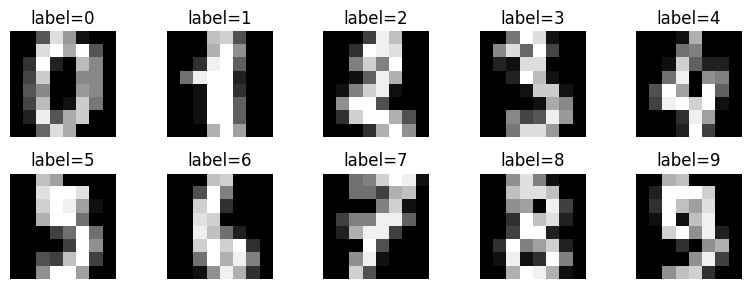

In [18]:
# Visualize a few samples
plt.figure(figsize=(8, 3))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(X_images[idx], cmap="gray")
    plt.title(f"label={labels[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_images,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (1257, 8, 8) (1257,)
Val:   (270, 8, 8) (270,)
Test:  (270, 8, 8) (270,)


In [20]:
class DigitsImageDataset(Dataset):
    """Torch dataset wrapper for scikit-learn digits images."""

    def __init__(self, images: np.ndarray, labels: np.ndarray):
        self.images = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.images[idx], self.labels[idx]


train_ds = DigitsImageDataset(X_train, y_train)
val_ds = DigitsImageDataset(X_val, y_val)
test_ds = DigitsImageDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

batch_images, batch_labels = next(iter(train_loader))
print(batch_images.shape, batch_labels.shape)

torch.Size([128, 1, 8, 8]) torch.Size([128])


In [21]:
class PatchEmbedding(nn.Module):
    """Convert small image patches into token embeddings."""

    def __init__(self, image_size: int = 8, patch_size: int = 2, in_channels: int = 1, d_model: int = 64):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size")

        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size
        self.projection = nn.Linear(self.patch_dim, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.contiguous().view(B, C, -1, p, p)
        patches = patches.permute(0, 2, 1, 3, 4).contiguous()
        patches = patches.view(B, self.num_patches, self.patch_dim)
        return self.projection(patches)

In [22]:
class CustomTransformerDigitsClassifier(nn.Module):
    """Small Vision Transformer-style classifier using our custom encoder blocks."""

    def __init__(
        self,
        image_size: int = 8,
        patch_size: int = 2,
        d_model: int = 64,
        num_heads: int = 4,
        d_ff: int = 128,
        num_layers: int = 2,
        num_classes: int = 10,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=1,
            d_model=d_model,
        )
        num_patches = self.patch_embedding.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, d_model) * 0.02)
        self.dropout = nn.Dropout(dropout)
        self.encoder = TransformerEncoderCustom(
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
        )
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.size(0)
        patch_tokens = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls_tokens, patch_tokens], dim=1)
        tokens = tokens + self.pos_embedding[:, : tokens.size(1), :]
        tokens = self.dropout(tokens)

        encoded, _ = self.encoder(tokens, src_mask=None)
        cls_representation = encoded[:, 0]
        logits = self.head(cls_representation)
        return logits

In [23]:
# Shape test for the classifier
model = CustomTransformerDigitsClassifier(
    image_size=8,
    patch_size=2,
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_layers=2,
    num_classes=10,
    dropout=0.1,
).to(DEVICE)

sample_logits = model(batch_images.to(DEVICE))
print("Batch images:", batch_images.shape)
print("Logits:      ", sample_logits.shape)

Batch images: torch.Size([128, 1, 8, 8])
Logits:       torch.Size([128, 10])


In [24]:
@dataclass
class TrainConfig:
    epochs: int = 25
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    grad_clip: float = 1.0


config = TrainConfig()
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
criterion = nn.CrossEntropyLoss()

In [25]:
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc

In [26]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_state = None
start_time = time.time()

for epoch in range(1, config.epochs + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

elapsed = time.time() - start_time
print(f"Training finished in {elapsed:.1f} seconds")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch 01 | train_loss=2.3638 train_acc=0.1002 | val_loss=2.3070 val_acc=0.1222
Epoch 02 | train_loss=2.3232 train_acc=0.1106 | val_loss=2.2888 val_acc=0.1704
Epoch 03 | train_loss=2.3072 train_acc=0.1042 | val_loss=2.2819 val_acc=0.1704
Epoch 04 | train_loss=2.3100 train_acc=0.1106 | val_loss=2.2682 val_acc=0.1704
Epoch 05 | train_loss=2.2843 train_acc=0.1504 | val_loss=2.2526 val_acc=0.2037
Epoch 06 | train_loss=2.2660 train_acc=0.1543 | val_loss=2.2142 val_acc=0.2407
Epoch 07 | train_loss=2.2344 train_acc=0.1718 | val_loss=2.1495 val_acc=0.2148
Epoch 08 | train_loss=2.1783 train_acc=0.2100 | val_loss=2.0813 val_acc=0.2778
Epoch 09 | train_loss=2.1216 train_acc=0.2283 | val_loss=2.0288 val_acc=0.2704
Epoch 10 | train_loss=2.0923 train_acc=0.2434 | val_loss=2.0836 val_acc=0.2444
Epoch 11 | train_loss=2.0540 train_acc=0.2586 | val_loss=2.0180 val_acc=0.2630
Epoch 12 | train_loss=2.0075 train_acc=0.2737 | val_loss=1.9109 val_acc=0.3111
Epoch 13 | train_loss=1.9619 train_acc=0.2856 | val_

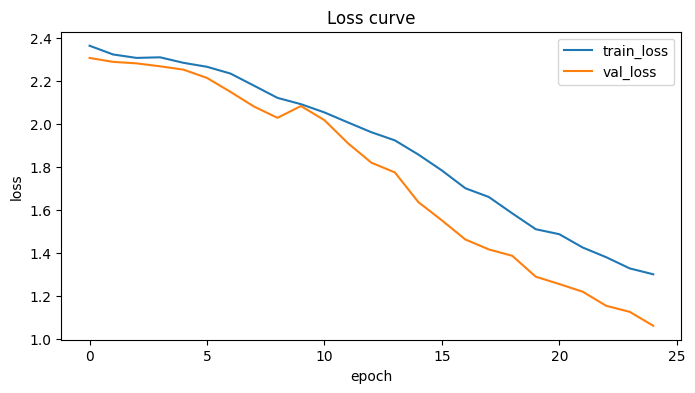

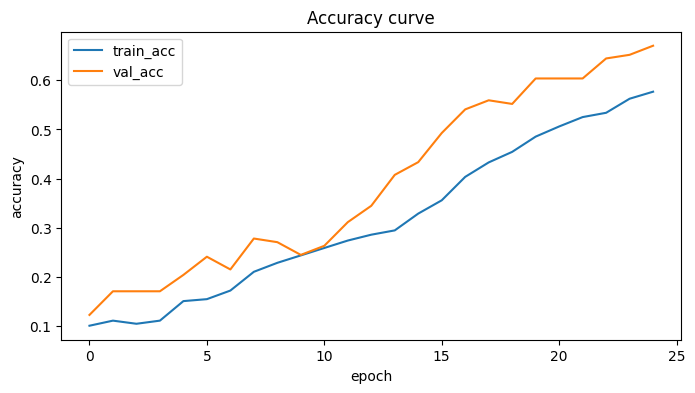

In [27]:
# Restore best validation checkpoint
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Accuracy curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [28]:
def predict_all(model, loader):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for images, y in loader:
            images = images.to(DEVICE)
            logits = model(images)
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            targets.extend(y.numpy().tolist())
    return np.array(targets), np.array(preds)


y_true, y_pred = predict_all(model, test_loader)
print("Test accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

Test accuracy: 0.7185185185185186
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.54      0.75      0.63        28
           2       0.81      0.65      0.72        26
           3       0.81      0.61      0.69        28
           4       0.81      0.78      0.79        27
           5       0.62      0.74      0.68        27
           6       0.85      0.85      0.85        27
           7       0.74      0.85      0.79        27
           8       0.54      0.54      0.54        26
           9       0.72      0.48      0.58        27

    accuracy                           0.72       270
   macro avg       0.73      0.72      0.72       270
weighted avg       0.73      0.72      0.72       270



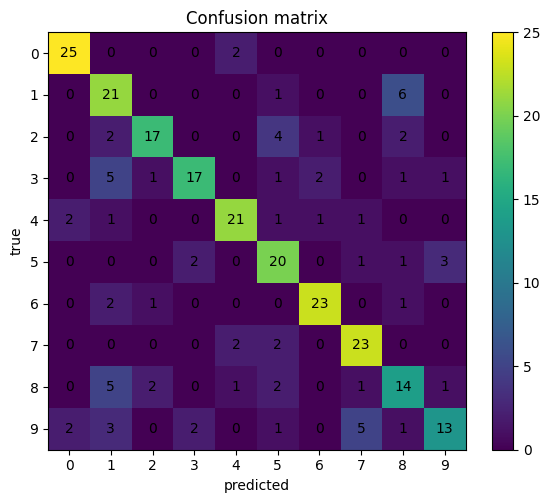

In [29]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.xticks(range(10), class_names)
plt.yticks(range(10), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

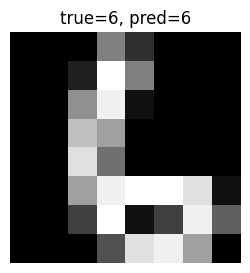

Class probabilities:
0: 0.0124
1: 0.0293
2: 0.0759
3: 0.2056
4: 0.0046
5: 0.0074
6: 0.5148
7: 0.0023
8: 0.0401
9: 0.1076


In [30]:
# Single-sample inference demo
model.eval()
sample_index = 0
image_tensor, true_label = test_ds[sample_index]
with torch.no_grad():
    logits = model(image_tensor.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_label = int(np.argmax(probs))

plt.figure(figsize=(3, 3))
plt.imshow(image_tensor.squeeze(0).numpy(), cmap="gray")
plt.title(f"true={true_label}, pred={pred_label}")
plt.axis("off")
plt.show()

print("Class probabilities:")
for class_id, prob in enumerate(probs):
    print(f"{class_id}: {prob:.4f}")

## What this full pipeline demonstrates

This project demonstrates several resume-ready points:

- PyTorch model design using OOP.
- Custom attention implementation.
- Custom Transformer encoder blocks.
- Dataset preparation from scikit-learn.
- Train/validation/test split with stratification.
- DataLoader usage.
- AdamW optimization.
- Gradient clipping.
- Model checkpointing based on validation accuracy.
- Evaluation using accuracy, classification report, and confusion matrix.

### Possible portfolio extension

The same structure can be extended into:

- Text classification with a tokenizer and embedding layer.
- Time-series classification by treating time windows as tokens.
- Tabular row modeling by treating feature groups as tokens.
- Image classification with larger images and patch embeddings.
- Encoder-decoder toy translation with synthetic data.

## Interview-ready mini explanations

### Explain Transformer in 30 seconds

A Transformer is an attention-based neural network that represents each token by comparing it with other tokens. It uses embeddings, positional information, multi-head self-attention, feed-forward layers, residual connections, layer normalization, and masking. Encoder-only models are strong for understanding tasks, decoder-only models are strong for generation, and encoder-decoder models are strong for sequence-to-sequence tasks.

### Explain Multi-Head Attention in 30 seconds

Multi-head attention projects input representations into queries, keys, and values across several heads. Each head computes scaled dot-product attention independently, then all heads are concatenated and projected back to the model dimension. This lets the model learn multiple relation patterns at the same time.

### Explain causal masking in 20 seconds

Causal masking blocks attention to future tokens during autoregressive training and generation. Without it, a decoder would see the answer token while predicting it, causing information leakage.

### Explain padding mask in 20 seconds

Padding masks stop fake padding tokens from contributing to attention and loss. They are necessary when batching sequences of different lengths.

## Debugging checklist

Before blaming the architecture, check:

1. Input shape: `[B, L, D]` or `[L, B, D]` depending on API.
2. `d_model % num_heads == 0`.
3. Mask shape broadcasts correctly to `[B, H, T, S]`.
4. Padding tokens are ignored in loss.
5. Training and validation splits are separate.
6. Learning rate is not too high.
7. Loss decreases on a small batch.
8. Model can overfit a tiny subset.
9. Gradients are finite.
10. Labels and logits align correctly.

## Small-batch overfit test

A reliable deep learning debugging pattern is to train on a tiny subset and check whether the model can overfit. If a model cannot overfit a tiny clean subset, there is often a bug in data flow, loss, labels, mask logic, or optimization.

In [31]:
# Optional tiny overfit test
# tiny_loader = DataLoader(torch.utils.data.Subset(train_ds, list(range(32))), batch_size=32, shuffle=True)
# tiny_model = CustomTransformerDigitsClassifier().to(DEVICE)
# tiny_optimizer = torch.optim.AdamW(tiny_model.parameters(), lr=1e-3)
# for epoch in range(50):
#     loss, acc = run_one_epoch(tiny_model, tiny_loader, optimizer=tiny_optimizer)
#     if (epoch + 1) % 10 == 0:
#         print(epoch + 1, loss, acc)